In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/predict-1-year-us-stock-returns-from-fundamentals/sample_submission.csv
/kaggle/input/competitions/predict-1-year-us-stock-returns-from-fundamentals/train.csv
/kaggle/input/competitions/predict-1-year-us-stock-returns-from-fundamentals/test.csv
/kaggle/input/datasets/sumeakash/mlp-architecture/mlp_architecture_32features.svg


# Import Libraries

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')
import random


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe"

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)



2026-06-07 09:21:17.978280: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780824078.159433      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780824078.211776      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780824078.646521      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780824078.646559      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780824078.646562      22 computation_placer.cc:177] computation placer alr

In [3]:
# ── Check GPU ─────────────────────────────────────────────────────────────────
print("GPUs:", tf.config.list_physical_devices('GPU'))


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Dataset Upload

In [4]:
def dataset_upload():
    train_path = '/kaggle/input/competitions/predict-1-year-us-stock-returns-from-fundamentals/train.csv'
    test_path = '/kaggle/input/competitions/predict-1-year-us-stock-returns-from-fundamentals/test.csv'
    try:
        if os.path.exists(train_path) and os.path.exists(test_path):
            
            train = pd.read_csv(train_path)
            test  = pd.read_csv(test_path)
            print('Dataset loaded successfully')
            
            
            return train,test
        else:
            print('file not found')


    except exception as e:
        raise Exception(f'Error while loading dataset:{e}')

train, test = dataset_upload()

train_df = train.sort_values(
    ['period_start', 'ticker']
).reset_index(drop=True)
train_df.head()
    

Dataset loaded successfully


,id,ticker,start_year,period_start,period_end,return_pct,pe_ttm,price_to_book,price_to_sales,growth_pe_ratio,...,inventory,current_ratio,quick_ratio,debt_to_equity,dividend_yield,dividends_ttm,dividends_paid_ttm,shares_outstanding,shares_diluted,sector_code
0,20023,BJRI,2019,2019-01-01,2019-12-31,-24.94,22.21,3.65,1.01,0.97,...,0.000000e+00,0.52,0.52,0.61,NaN,NaN,NaN,2.105800e+07,2.158400e+07,4.0
1,17204,CAKE,2019,2019-01-01,2019-12-31,-10.69,21.89,3.80,0.93,0.50,...,3.888600e+07,0.47,0.38,0.02,2.60,56251000.0,NaN,NaN,4.621500e+07,4.0
2,1091,MDT,2019,2019-01-25,2020-01-24,37.05,22.68,2.24,3.65,-1.16,...,3.866000e+09,2.36,1.92,0.48,NaN,NaN,NaN,1.340593e+09,1.352700e+09,3.0
3,6738,NTAP,2019,2019-01-25,2020-01-24,-6.15,12.09,10.26,2.15,0.25,...,1.000000e+08,1.56,1.53,1.86,2.85,359000000.0,NaN,2.470000e+08,2.550000e+08,0.0
4,10699,AVAV,2019,2019-01-26,2020-01-25,-13.68,94.24,8.63,40.77,0.33,...,5.037900e+07,10.46,9.25,0.00,NaN,NaN,NaN,2.393246e+07,2.408182e+07,2.0


In [5]:
id = test['id']

# Basic details of dataset

In [6]:
def basic_information(train):
    """here check basic information of this dataset like missing, data types etc"""
    

    print('The deatils of dataset: ')
    print('=' * 65)
    #shape of dataset
    print('The shape of training dataset are :')
    print(train.shape)

    print('=' * 65)
    #check dtypes of feature
    print('The data types of feature are: ')
    print(train.info())

    print('=' * 65)
    #check total duplicates data
    print('The total number of duplicates data are :')
    print(train.duplicated().sum())

    print('=' * 65)
    # check missing data and their percentage
    print('Missing Dataset Info: ')
    missing_data = train.isnull().sum()
    missing_percentage = (missing_data/len(train)) * 100
    missing = pd.DataFrame({'Missing_data': missing_data,
                            'Missing_Percentage': missing_percentage})
    print(
    missing.sort_values(
        by='Missing_Percentage',
        ascending=False
    )
)

basic_information(train_df)

The deatils of dataset: 
The shape of training dataset are :
(23070, 39)
The data types of feature are: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23070 entries, 0 to 23069
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   23070 non-null  int64  
 1   ticker               23070 non-null  object 
 2   start_year           23070 non-null  int64  
 3   period_start         23070 non-null  object 
 4   period_end           23070 non-null  object 
 5   return_pct           23070 non-null  float64
 6   pe_ttm               20694 non-null  float64
 7   price_to_book        17537 non-null  float64
 8   price_to_sales       19357 non-null  float64
 9   growth_pe_ratio      15054 non-null  float64
 10  gross_margin         8660 non-null   float64
 11  operating_margin     19351 non-null  float64
 12  net_margin           20379 non-null  float64
 13  roa                  18387 non-

Dividend-related features have more than 70% missing values.

In [7]:
#reduce the memory
for col in train_df.columns:
    
    if train_df[col].dtype == 'float64':
        train_df[col] = train_df[col].astype('float32')
        
    elif train_df[col].dtype == 'int64':
        train_df[col] = train_df[col].astype('int32')

In [8]:
#Basic Statistics
train_df.describe()

,id,start_year,return_pct,pe_ttm,price_to_book,price_to_sales,growth_pe_ratio,gross_margin,operating_margin,net_margin,...,inventory,current_ratio,quick_ratio,debt_to_equity,dividend_yield,dividends_ttm,dividends_paid_ttm,shares_outstanding,shares_diluted,sector_code
count,23070.000000,23070.000000,23070.000000,2.069400e+04,1.753700e+04,19357.000000,15054.000000,8660.000000,1.935100e+04,20379.000000,...,1.155600e+04,15676.000000,15676.000000,14478.000000,6453.000000,6.734000e+03,1.565000e+03,1.490900e+04,1.818300e+04,22966.000000
mean,11534.500000,2020.620156,18.778738,4.419552e+06,1.318639e+03,38.474636,0.812582,64.951530,-4.193572e+02,-134.911575,...,1.330403e+09,2.893604,2.545414,31.808599,5.989950,5.273457e+08,3.811204e+08,3.014210e+08,3.480356e+08,3.137159
std,6659.879691,1.116563,138.649460,1.847726e+08,5.618214e+04,623.703003,14.546037,2091.936523,1.270669e+04,4522.541992,...,4.310532e+09,5.969102,5.976909,1036.165527,132.826324,1.592583e+09,1.664417e+09,1.867545e+09,2.601353e+09,2.609421
min,0.000000,2019.000000,-99.169998,-2.378991e+08,-1.393592e+05,0.000000,-100.000000,-82762.500000,-1.237600e+06,-218214.093750,...,-3.700000e+06,-2.110000,-1.640000,-12453.559570,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,5767.250000,2020.000000,-19.787501,-3.400000e-01,1.440000e+00,1.060000,0.000000,25.117500,1.390000e+00,0.170000,...,3.628494e+07,1.150000,0.920000,0.010000,0.000000,0.000000e+00,0.000000e+00,4.496902e+07,4.447116e+07,1.000000
50%,11534.500000,2021.000000,3.500000,1.521000e+01,2.960000e+00,2.650000,0.690000,38.605000,1.022000e+01,7.270000,...,2.802000e+08,1.700000,1.350000,0.650000,0.680000,2.761000e+07,0.000000e+00,9.750000e+07,9.832232e+07,3.000000
75%,17301.750000,2022.000000,33.827501,3.042750e+01,6.610000e+00,6.350000,2.050000,56.525002,2.050500e+01,16.040001,...,1.056998e+09,2.840000,2.290000,1.570000,2.470000,2.903675e+08,2.237000e+08,2.382685e+08,2.550000e+08,5.000000
max,23069.000000,2022.000000,10571.110352,1.251553e+10,5.271275e+06,53118.761719,100.000000,137639.687500,9.353684e+04,104247.687500,...,8.696100e+10,211.520004,211.520004,69786.500000,7310.330078,2.008700e+10,2.434000e+10,1.217753e+11,1.751079e+11,10.000000


# Target Analysis

<Axes: xlabel='return_pct', ylabel='Count'>

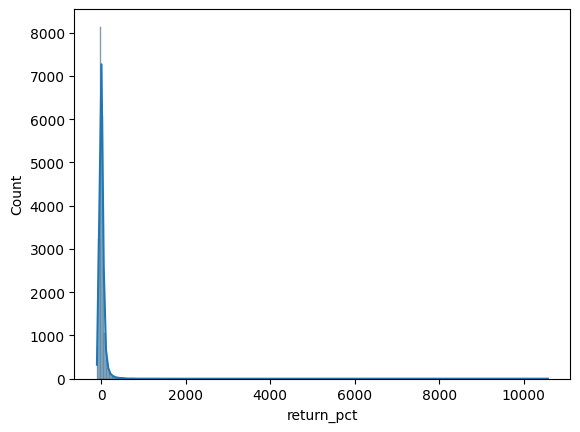

In [9]:
sns.histplot(train_df["return_pct"], kde=True)

In [10]:
positive_pct = (train_df['return_pct'] > 0).mean() * 100
negative_pct = (train_df['return_pct'] <= 0).mean() * 100

print(f'Average Positive return is: {positive_pct}')
print(f'Average Negative return is: {negative_pct}')

Average Positive return is: 53.76246207195492
Average Negative return is: 46.23753792804508


Across the training dataset, 53.76% of observations generated positive future returns, while 46.24% generated non-positive returns. This indicates a relatively balanced target distribution.

In [11]:
# check skawness
print("Skewness:", skew(train_df['return_pct']))
print("Kurtosis:", kurtosis(train_df['return_pct']))

Skewness: 38.278347
Kurtosis: 2328.7288


The target distribution is extremely right-skewed.

In [12]:
train_df['return_pct'].quantile([
    0.01,0.05,0.10,
    0.25,0.50,
    0.75,0.90,
    0.95,0.99,0.999
])

0.010     -80.195501
0.050     -56.198500
0.100     -41.152001
0.250     -19.787501
0.500       3.500000
0.750      33.827501
0.900      76.523997
0.950     118.077000
0.990     299.166006
0.999    1241.339816
Name: return_pct, dtype: float64

* 25% of observations lost more than 19.8%.
* Median return is 3.5%.
* 75% of observations returned less than 33.8%.
* Top 10% of observations returned more than 76.5%.
* Top 1% of observations returned more than 299%.
* Top 0.1% of observations returned more than 1241%.

In [13]:
bins = [-100, 0, 25, 50, 100, 500, np.inf]
labels = ['Loss', '0-25%', '25-50%', '50-100%', '100-500%', '>500%']

train_df['return_bucket'] = pd.cut(train_df['return_pct'], bins=bins, labels=labels)

train_df['return_bucket'].value_counts(normalize=True)*100

return_bucket
Loss        46.237538
0-25%       23.185956
25-50%      13.177287
50-100%     10.862592
100-500%     6.163849
>500%        0.372779
Name: proportion, dtype: float64

Nearly half of the observations (46.24%) resulted in losses, while the majority of positive-return observations generated returns below 100%. Only 6.16% of observations achieved returns between 100% and 500%, and just 0.37% exceeded 500%.

In [14]:
#here find those stock name who is returning more than 500% within one yaer
high_return_stocks = train_df[
    train_df['return_pct'] > 500
][['ticker', 'start_year', 'return_pct']]

high_return_stocks.sort_values(
    'return_pct',
    ascending=False
)

,ticker,start_year,return_pct
5881,MARA,2020,10571.110352
5113,GME,2020,8363.540039
6084,RIOT,2020,6294.959961
5376,AMTX,2020,4615.379883
7727,GME,2020,3917.949951
...,...,...,...
7989,AMPY,2020,525.880005
19388,SMCI,2022,517.719971
6078,REZI,2020,511.570007
6243,VCEL,2020,505.779999


<Axes: xlabel='start_year', ylabel='return_pct'>

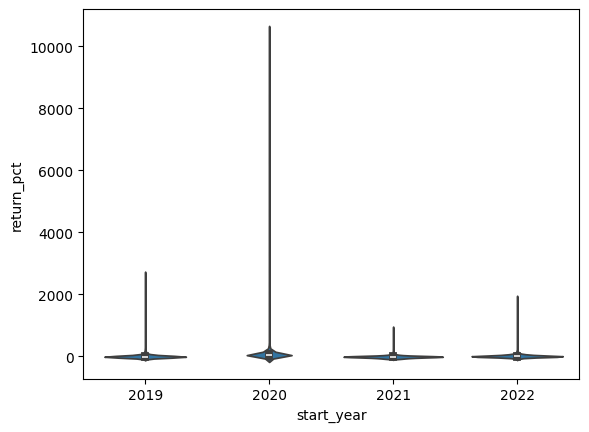

In [15]:
# Year Analysis
sns.violinplot(
    x='start_year',
    y='return_pct',
    data=train_df
)

In [16]:
# Year Analysis
year_stats = train_df.groupby('start_year')['return_pct'].agg(
    ['mean', 'median', 'std', 'min', 'max']
)
print(year_stats)

                 mean     median         std        min           max
start_year                                                           
2019         4.098202  -7.700000   86.715607 -97.010002   2701.760010
2020        73.873787  42.790001  254.149368 -87.989998  10571.110352
2021       -10.513654 -12.155000   41.156769 -97.959999    944.809998
2022        12.360605   3.260000   64.771950 -99.169998   1932.829956


The target variable exhibits substantial variation across years. Returns in 2020 were significantly higher and more volatile than in other periods, with a mean return of 73.87% and a standard deviation of 254.15%. Across all years, the mean return exceeds the median return, indicating a heavily right-skewed distribution where a small number of extreme winners drive average performance. This behavior is typical in equity markets and highlights the challenge of predicting future stock returns.

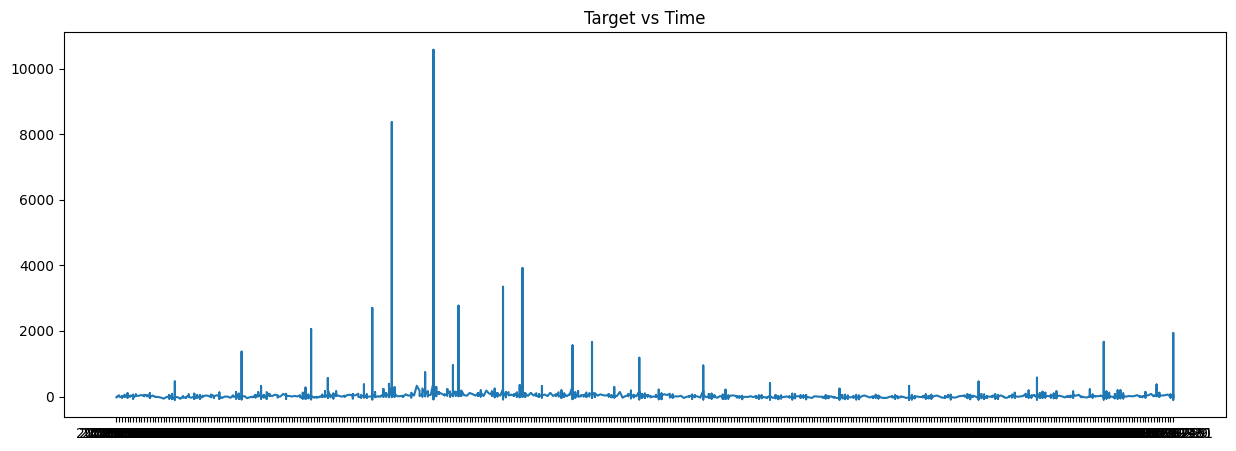

In [17]:
plt.figure(figsize=(15,5))
plt.plot(train_df['period_start'], train_df['return_pct'])
plt.title("Target vs Time")
plt.show()

In [18]:
#Sector Analysis
sector_stats = train_df.groupby('sector_code')['return_pct'].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
])

sector_stats

,count,mean,median,std,min,max
sector_code,,,,,,
0.0,3695,21.081575,8.600,71.743759,-93.260002,922.219971
1.0,3840,12.459454,-0.655,121.911850,-99.169998,6294.959961
2.0,3542,21.181684,7.635,197.020416,-94.080002,10571.110352
3.0,3180,21.915524,1.450,155.274841,-95.889999,4615.379883
4.0,2837,26.139912,5.120,201.052109,-97.959999,8363.540039
5.0,1601,2.189844,-5.080,42.170887,-86.940002,286.750000
6.0,1166,27.699133,7.280,94.211632,-97.010002,1496.959961
7.0,1086,12.902578,4.475,65.648430,-81.820000,1041.329956
8.0,919,35.091099,18.490,116.238564,-94.169998,1559.119995


Sector-level analysis reveals substantial variation in future stock returns. Sector 8 demonstrates the strongest performance, with both the highest mean return (35.1%) and the highest median return (18.5%), suggesting broad-based strength rather than dependence on a few outliers. In contrast, sectors 5, 9, and 10 exhibit negative median returns, indicating weaker overall performance. Several sectors show large gaps between mean and median returns, highlighting the presence of extreme positive-return observations that skew average performance.

# Features Analysis

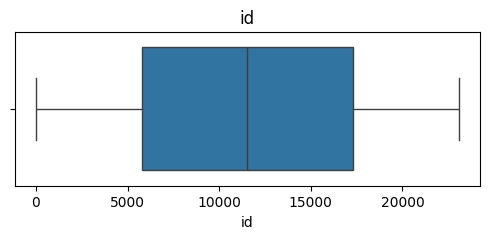

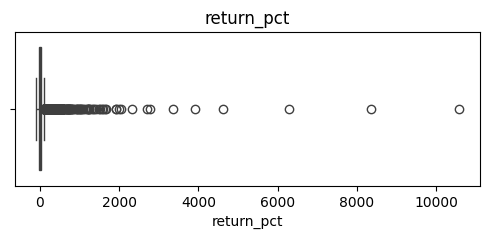

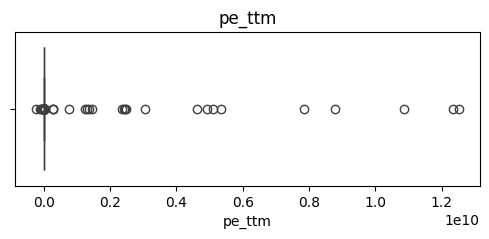

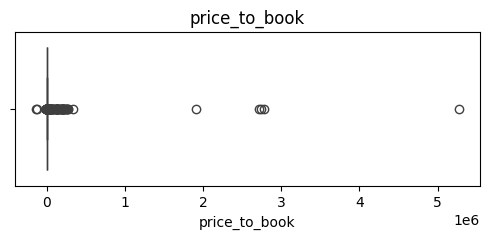

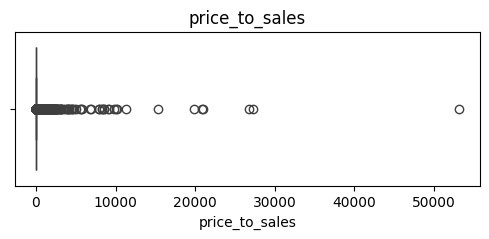

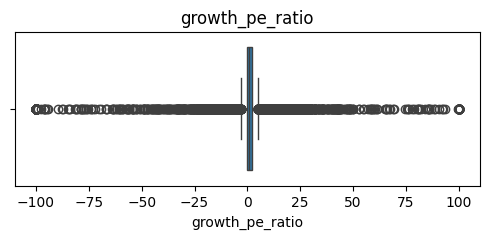

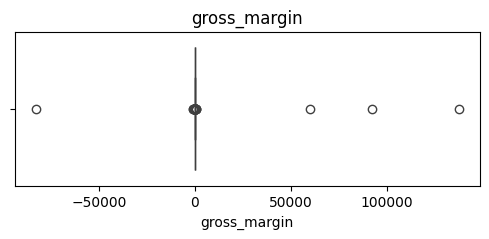

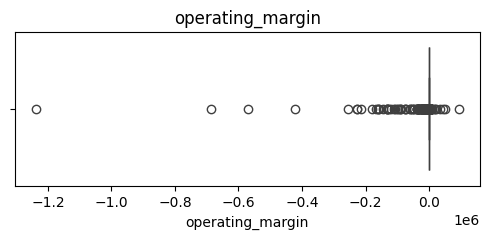

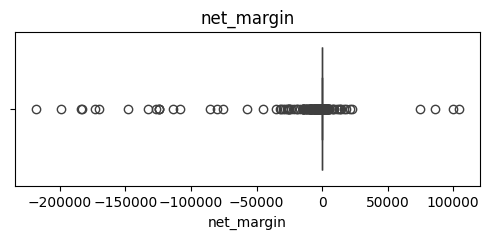

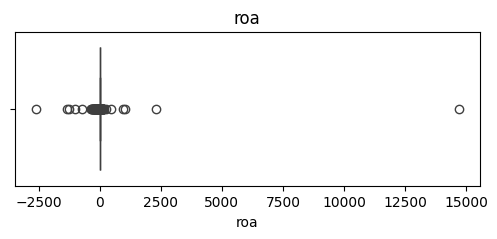

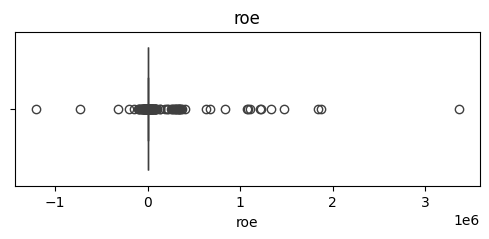

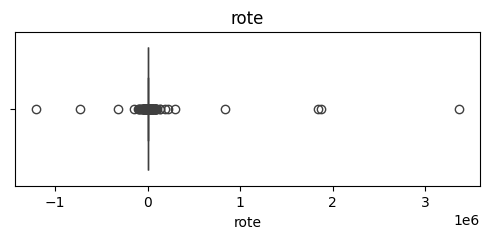

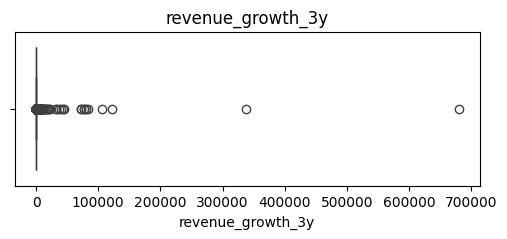

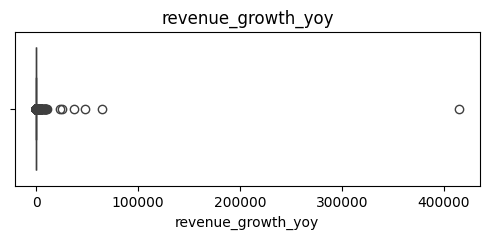

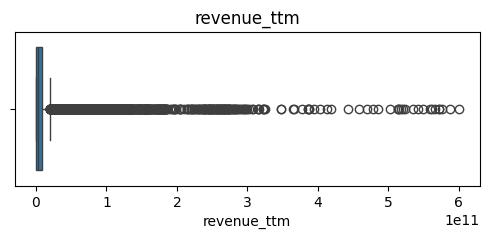

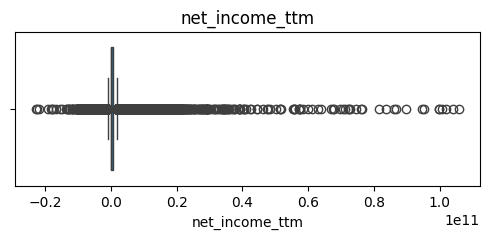

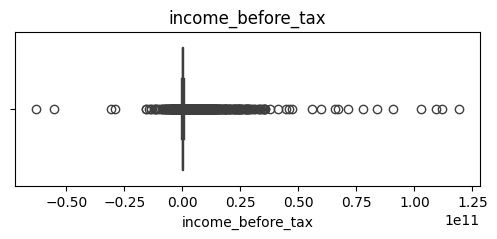

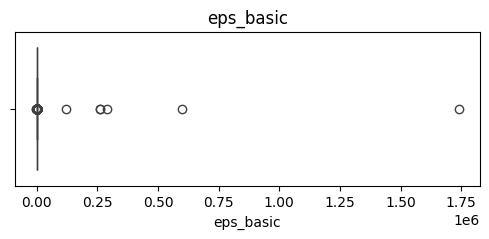

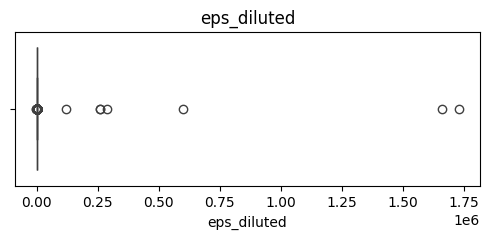

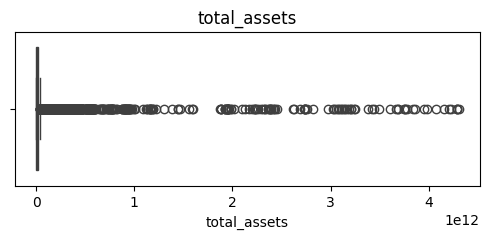

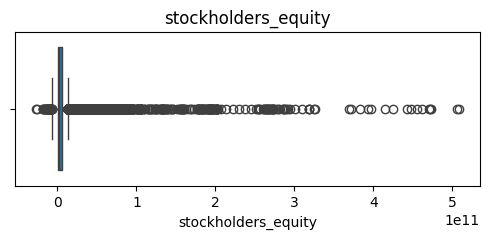

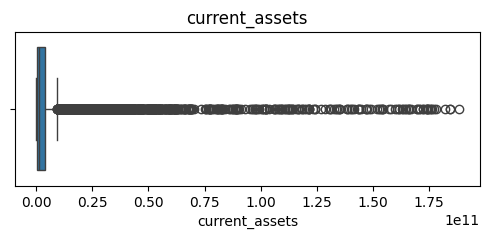

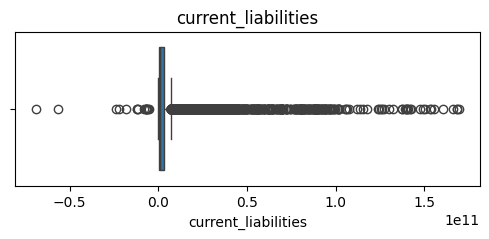

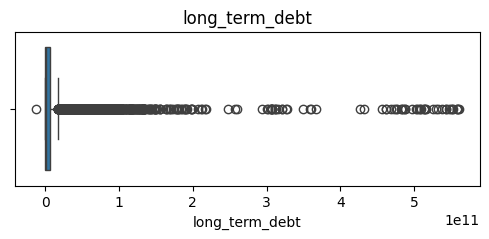

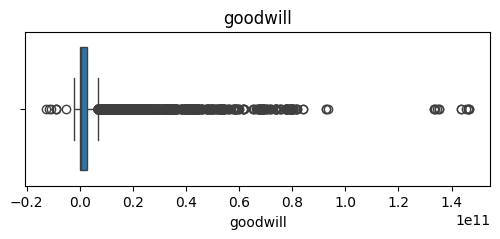

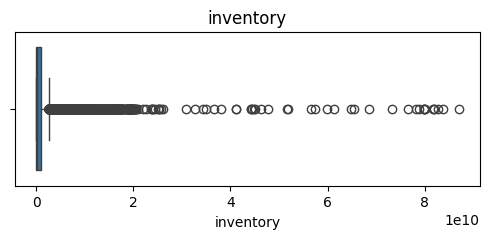

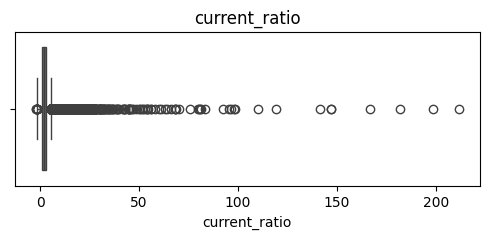

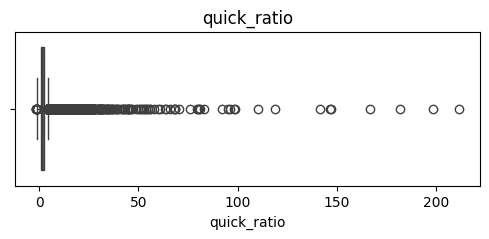

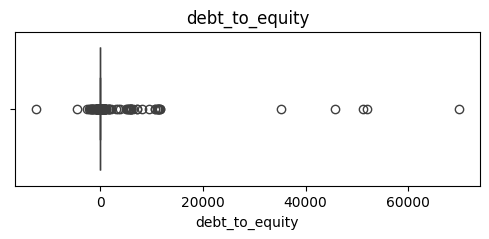

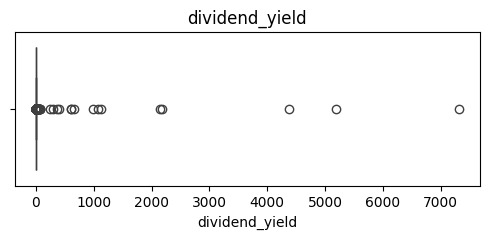

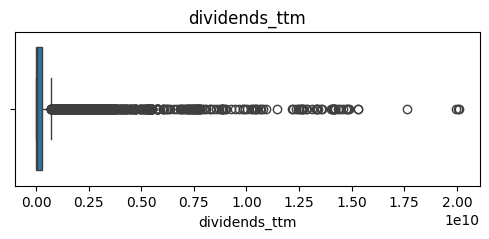

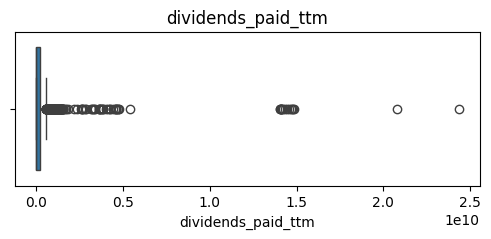

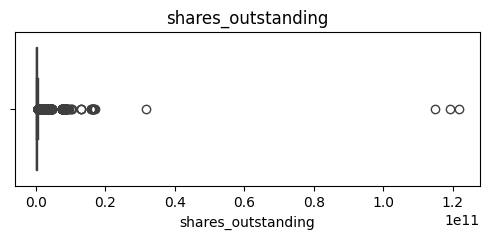

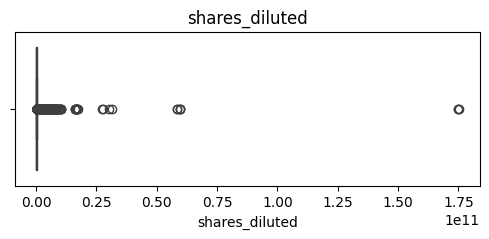

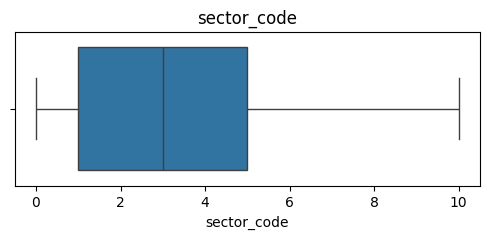

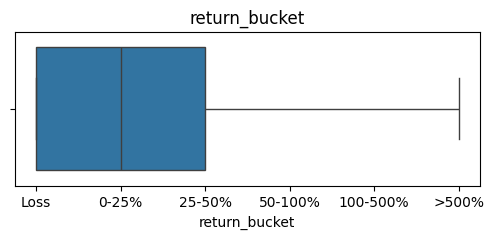

In [19]:
num_cols = train_df.select_dtypes(exclude = ['object']).columns
num_cols = num_cols.drop(['start_year'])
for col in num_cols:
    plt.figure(figsize = (6,2))
    sns.boxplot(x = train_df[col])
    plt.title(col)
    plt.show()
    

Some features are heaivy tailed distribution and Some features are highly right skewed. 

In [20]:
def check_noise_data(train_df, method='clip'):
    """
    Handle negative values in features that should theoretically be non-negative.
    Negative observations are rare and may result from data extraction or
    reporting anomalies. Two approaches are tested: clipping to zero and
    converting to absolute values. The best method is selected based on
    model performance.
    """
    
    non_negative_cols = [
        'revenue_ttm',
        'total_assets',
        'current_ratio',
        'quick_ratio',
        'current_assets',
        'current_liabilities',
        'long_term_debt',
        'goodwill',
        'inventory',
        'shares_outstanding',
        'shares_diluted',
        'dividend_yield',
        'dividends_ttm',
        'dividends_paid_ttm'
    ]

    train_df = train_df.copy()

    for col in non_negative_cols:
        negative_count = (train_df[col] < 0).sum()
        negative_pct = (train_df[col] < 0).mean() * 100

        print(f'\nColumn: {col}')
        print(f'MInimum value is: {train_df[col].min()}')
        print(f'Total negative values: {negative_count}')
        print(f'Percentage negative: {negative_pct:.4f}%')
        
        if method == 'clip':
            train_df[col] = train_df[col].clip(lower=0)

        elif method == 'abs':
            train_df[col] = train_df[col].abs()

        print('-' * 60)

    return train_df

train_clip = check_noise_data(train_df, method = 'clip')
df_train = check_noise_data(train_df, method = 'abs')



Column: revenue_ttm
MInimum value is: 0.0
Total negative values: 0
Percentage negative: 0.0000%
------------------------------------------------------------

Column: total_assets
MInimum value is: -146979008.0
Total negative values: 1
Percentage negative: 0.0043%
------------------------------------------------------------

Column: current_ratio
MInimum value is: -2.109999895095825
Total negative values: 19
Percentage negative: 0.0824%
------------------------------------------------------------

Column: quick_ratio
MInimum value is: -1.6399999856948853
Total negative values: 41
Percentage negative: 0.1777%
------------------------------------------------------------

Column: current_assets
MInimum value is: -57545000.0
Total negative values: 4
Percentage negative: 0.0173%
------------------------------------------------------------

Column: current_liabilities
MInimum value is: -69045002240.0
Total negative values: 22
Percentage negative: 0.0954%
-------------------------------------

In [21]:
important_cols = [
    'return_pct',
    'pe_ttm',
    'price_to_book',
    'revenue_growth_yoy',
    'roe'
]

train_df[important_cols].quantile(
    [0.50, 0.90, 0.95, 0.99, 0.999]
)

,return_pct,pe_ttm,price_to_book,revenue_growth_yoy,roe
0.500,3.500000,1.521000e+01,2.960000,8.200000,10.250000
0.900,76.523997,6.540800e+01,16.317999,48.653999,43.029999
0.950,118.077000,1.214640e+02,35.243999,81.681999,83.869995
0.990,299.166006,1.072758e+03,1028.783203,362.690399,1308.383423
0.999,1241.339816,2.692677e+08,202418.921875,5209.608398,336428.218750


Several features show strong right-skewness and extreme outliers. The large gap between median and upper percentiles suggests substantial variation in company size, profitability, and growth across the dataset.

In [22]:

#ROE = (Net Income/Shareholder 's Equity) * 100

train.nlargest(10, 'roe')[
    ['ticker','roe','stockholders_equity','net_income_ttm']
]

,ticker,roe,stockholders_equity,net_income_ttm
16970,GRND,3361580.43,690.0,23194905.0
17041,HPK,1872545.45,11000.0,205980000.0
16964,GRND,1838861.88,690.0,12688147.0
20655,PAHC,1470225.00,4000.0,58809000.0
20662,PAHC,1332025.00,4000.0,53281000.0
20656,PAHC,1229375.00,4000.0,49175000.0
20661,PAHC,1215425.00,4000.0,48617000.0
20666,PAHC,1106150.00,4000.0,44246000.0
20665,PAHC,1083475.00,4000.0,43339000.0
20659,PAHC,1072650.00,4000.0,42906000.0


Extreme ROE outliers are caused by near-zero shareholder equity, which inflates the ratio and produces unusually large values.

In [23]:
skew_df = train_df.select_dtypes(include='number').skew()

skew_df.sort_values(ascending=False)

revenue_growth_yoy     125.493286
eps_basic              120.473785
roa                    114.492363
eps_diluted             93.353508
revenue_growth_3y       85.890366
price_to_book           69.278679
rote                    67.772377
shares_diluted          53.597172
pe_ttm                  52.664845
shares_outstanding      52.406548
price_to_sales          49.117695
debt_to_equity          47.558826
roe                     42.290607
dividend_yield          42.187172
gross_margin            38.302303
return_pct              38.280838
quick_ratio             15.714651
current_ratio           15.625372
income_before_tax       15.151508
total_assets            13.082678
inventory               11.382600
net_income_ttm          11.053750
long_term_debt           9.992699
stockholders_equity      9.474319
dividends_paid_ttm       8.608749
revenue_ttm              8.186794
current_assets           6.829092
current_liabilities      6.424895
goodwill                 5.949303
dividends_ttm 

Most financial features exhibit substantial positive skewness, indicating the presence of extreme values and large differences across companies. Features such as Revenue Growth YoY (125.49), EPS Basic (120.47), ROA (114.49), Revenue Growth 3Y (85.89), and Price-to-Book (69.28) are highly right-skewed. This suggests that a small number of companies have exceptionally high growth rates, profitability metrics, or valuation ratios compared to the majority of firms.

In [24]:
# Revenue Growth vs Return
train_df['growth_bin'] = pd.qcut(
    train_df['revenue_growth_yoy'],
    q=5,
    duplicates='drop'
)

train_df.groupby('growth_bin')['return_pct'].median()

growth_bin
(-99.971, -3.14]       15.73
(-3.14, 4.674]          6.98
(4.674, 12.26]          4.40
(12.26, 26.65]          1.70
(26.65, 414794.438]    -0.30
Name: return_pct, dtype: float32

In [25]:
#ROE vs Return
train_df['roe_bin'] = pd.qcut(
    train_df['roe'],
    q=5,
    duplicates='drop'
)

train_df.groupby('roe_bin')['return_pct'].median()

roe_bin
(-1206823.751, -4.18]    7.895
(-4.18, 7.12]            4.190
(7.12, 13.5]             2.480
(13.5, 25.48]            4.930
(25.48, 3361580.5]       7.080
Name: return_pct, dtype: float32

The relationship between ROE and future returns is not linear.

In [26]:
#P/E vs Return
train_df['pe_bin'] = pd.qcut(
    train_df['pe_ttm'],
    q=5,
    duplicates='drop'
)

train_df.groupby('pe_bin')['return_pct'].median()

pe_bin
(-237899088.001, -7.88]     2.30
(-7.88, 10.802]            10.10
(10.802, 20.11]             3.32
(20.11, 36.43]              4.19
(36.43, 12515525632.0]      3.36
Name: return_pct, dtype: float32

* P/E alone is not a strong predictor of future returns.
* The relationship between P/E and future returns is not linear.

In [27]:

selected_cols = [
    'return_pct',
    'pe_ttm',
    'price_to_book',
    'price_to_sales',
    'roe',
    'roa',
    'revenue_growth_yoy',
    'debt_to_equity',
    'current_ratio',
    'dividend_yield'
]

corr = train_df[selected_cols].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlation Between Key Financial Features"
)

fig.show()

Dividend Yield has the highest correlation with future returns, although the correlation is weak (~0.09).

In [28]:
corr = train_df.corr(numeric_only=True)['return_pct']

print(
    corr.abs()
        .sort_values(ascending=False)
        .head(20)
)

return_pct             1.000000
dividend_yield         0.094959
start_year             0.052942
growth_pe_ratio        0.050707
dividends_paid_ttm     0.035171
goodwill               0.028519
long_term_debt         0.025231
net_income_ttm         0.024221
id                     0.023193
income_before_tax      0.020608
dividends_ttm          0.020246
shares_outstanding     0.020190
stockholders_equity    0.019968
roa                    0.019680
current_liabilities    0.019617
total_assets           0.017632
current_assets         0.017308
inventory              0.016612
revenue_ttm            0.014480
revenue_growth_3y      0.011623
Name: return_pct, dtype: float64


**Future stock returns show almost no linear relationship with individual fundamental features. This suggests that stock performance is influenced by complex nonlinear interactions rather than any single financial metric.**

In [29]:
growth_med = train_df['revenue_growth_yoy'].median()

train_df['growth_group'] = np.where(
    train_df['revenue_growth_yoy'] > growth_med,
    'High Growth',
    'Low Growth'
)





pivot_df = pd.pivot_table(
    train_df,
    values='return_pct',
    index='sector_code',
    columns='growth_group',
    aggfunc='median'
).reset_index()


fig = px.bar(
    pivot_df,
    x="sector_code",
    y=["High Growth", "Low Growth"],
    barmode="group",
    text_auto=".2f",
    title="Sector-wise Median Returns"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    title_x=0.5,
    yaxis_title="Median Return (%)",
    xaxis_title="Sector Code"
)

fig.show()

**High-growth companies did not consistently outperform low-growth companies across sectors. This indicates that future stock returns depend on multiple factors beyond revenue growth alone.**

# Data Preprocessing

In [30]:
def drop_features(train_df, test):
    """Here drop which feature is more than 70% missing value and id"""

    train_df = train_df.copy()
    test = test.copy()

    
    drop_cols = ['id',
                 'ticker',
                 'period_start',
                 'period_end',
                 'growth_group',
                 'roe_bin',
                 'growth_bin',
                 'pe_bin',
                 'return_bucket',
                ]
    
    drop_cols_test = ['id',
                      'ticker',
                      ]

    train_df = train_df.drop(columns = drop_cols)

    test = test.drop(columns = drop_cols_test)

    return train_df, test

train_df, test = drop_features(train_df, test)

In [31]:
def split_training_data(train_df):
    """Here split the training data in 5 times through Time series split"""

    train_df = train_df.copy()

    X = train_df.drop(columns = ['return_pct'])
    y = train_df['return_pct']

    tscv = TimeSeriesSplit(n_splits = 5)

    return X, y, tscv
        

X, y, tscv = split_training_data(train_df)

In [32]:
def impute_value(X, test):
    """Here all missing value is filling through median and 0 And add indicators"""

    X    = X.copy()
    
    high_missing_cols = [
    'dividends_paid_ttm',   # 93%
    'dividend_yield',       # 72%
    'dividends_ttm',        # 71%
    'gross_margin',         # 62%
    'inventory',            # 50%
    'debt_to_equity',       # 37%
    'growth_pe_ratio',      # 35%
    'current_ratio',        # 32%
    'quick_ratio'           # 32%
]
    
    for col in high_missing_cols:
        X[f'{col}_missing'] = X[col].isna().astype(np.int8)
        test[f'{col}_missing'] = test[col].isna().astype(np.int8)
        



# Financial ratios → use median
    ratio_cols = [
    'pe_ttm',
    'price_to_book',
    'price_to_sales',
    'growth_pe_ratio',
    'current_ratio',
    'quick_ratio',
    'debt_to_equity',
    'roa',
    'roe',
    'rote'
]


#Margins → use median
    margin_cols = [
    'gross_margin',
    'operating_margin',
    'net_margin'
]


#Assets, revenue, income → use median
    financial_cols = [
    'revenue_ttm',
    'net_income_ttm',
    'income_before_tax',
    'total_assets',
    'stockholders_equity',
    'current_assets',
    'current_liabilities',
    'long_term_debt',
    'shares_outstanding',
    'shares_diluted'
]
    
    #Earnings Per Share
    eps_cols = ['eps_basic', 'eps_diluted']




    for col in ratio_cols + margin_cols + financial_cols + eps_cols:
        median_val = X[col].median()
        X[col]     = X[col].fillna(median_val)
        test[col]  = test[col].fillna(median_val)

    

#Growth features → fill with 0
#If growth is unavailable, assuming "no growth information" as 0 is often a reasonable baseline.
    growth_cols = [
    'revenue_growth_3y',
    'revenue_growth_yoy'
]
        # Do not pay dividends
    divident_cols = [
    'dividend_yield',
    'dividends_ttm',
    'dividends_paid_ttm'
]

    for col in growth_cols + divident_cols:
        X[col]     = X[col].fillna(0)
        test[col]  = test[col].fillna(0)
        

#Inventory → fill with 0
#Many companies (software, consulting, financial firms) have no inventory.
    X['inventory']     = X['inventory'].fillna(0)
    test['inventory']  = test['inventory'].fillna(0)


#Goodwill → fill with 0
#Many companies have no goodwill.
    X['goodwill']     = X['goodwill'].fillna(0)
    test['goodwill']  = test['goodwill'].fillna(0)
    
    

#Sector code -> use mode
#Only about 0.45% missing.
    mode_val            = X['sector_code'].mode()[0]
    X['sector_code']    = X['sector_code'].fillna(mode_val)
    test['sector_code'] = test['sector_code'].fillna(mode_val)

    return X, test


# Transform Features

In [33]:
def transform_feature(X, test):
    """Log transform highly skewed monetary features."""

    X = X.copy()
    test = test.copy()

    money_cols = [
        'current_assets',
        'current_liabilities',
        'long_term_debt',
        'goodwill',
        'inventory'
    ]

    for col in money_cols:
        X[col] = np.log1p(X[col].clip(lower=0))
        test[col] = np.log1p(test[col].clip(lower=0))

    return X, test

# Training Process

# method -1: by clip 0

In [34]:
def evaluate_model(model, model_name, X, tscv, test, y):
    rmse_scores = []
    r2_scores   = []
    mae_scores  = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):

        
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[val_idx].copy()

        y_train = y.iloc[train_idx].copy()
        y_valid = y.iloc[val_idx].copy()

        # call impute fxn
        X_train, X_valid = impute_value(X_train, X_valid)
    

        # Simple prediction by mean
        baseline_pred = np.repeat(y_train.mean(), len(y_valid))

        print(
            "Baseline MAE:",
            mean_absolute_error(y_valid, baseline_pred)
        )

        # train model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_valid)
        mae = mean_absolute_error(y_valid, y_pred)
        rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
        r2 = r2_score(y_valid, y_pred)

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        r2_scores.append(r2)

        print(f'{model_name} | Fold {fold} | RMSE: {rmse:.4f} | R2: {r2:.4f}')
        

        train_pred = model.predict(X_train)

        print(
            "MAE of training data: ",
            mean_absolute_error(y_train, train_pred)
        )

        print(
            "R2 of training data: ",
            r2_score(y_train, train_pred)
        )

        print("-" * 60)

    # full training set
    X_full_train = X.copy()
    test_df      = test.copy()

    X_train_full, test_df = impute_value(
                            X_full_train,
                            test_df
                         )
    
    model.fit(X_train_full, y)

    return {
        'model': model,
        'test_df': test_df,
        'X_full_train': X_train_full,
        'avg_mae': np.mean(mae_scores),
        'avg_rmse': np.mean(rmse_scores),
        'avg_r2': np.mean(r2_scores)
    }

# Model-1 -> RandomForest

In [35]:
rf_model = RandomForestRegressor(
    n_estimators=300,     
    max_depth=12,
    min_samples_leaf=10,   
    max_features=0.6,      
    max_samples=0.8,      
    bootstrap=True,        
    random_state=42,
    n_jobs=-1
)

rf_result = evaluate_model(
    rf_model,
    'RandomForest',
    X,
    tscv,
    test,
    y
    )

Baseline MAE: 87.30781555175781
RandomForest | Fold 1 | RMSE: 298.9832 | R2: -0.0513
MAE of training data:  23.680563595533865
R2 of training data:  0.3761015623257703
------------------------------------------------------------
Baseline MAE: 43.792945861816406
RandomForest | Fold 2 | RMSE: 121.2195 | R2: -0.3656
MAE of training data:  41.41089041922876
R2 of training data:  0.2715936386609493
------------------------------------------------------------
Baseline MAE: 55.791385650634766
RandomForest | Fold 3 | RMSE: 53.4278 | R2: -1.2873
MAE of training data:  40.010211684970486
R2 of training data:  0.2835049008492535
------------------------------------------------------------
Baseline MAE: 40.39556884765625
RandomForest | Fold 4 | RMSE: 45.2626 | R2: -0.0448
MAE of training data:  34.96837743717601
R2 of training data:  0.2988071176565802
------------------------------------------------------------
Baseline MAE: 35.400856018066406
RandomForest | Fold 5 | RMSE: 72.6313 | R2: 0.0623
MA

# Method -2 by abs 

In [36]:
df_train = df_train.drop(columns = ['id',
                 'ticker',
                 'period_start',
                 'period_end',
                    'return_bucket'])


In [37]:

X1,y1,tscv1 =  split_training_data(df_train)

rf_model1 =  RandomForestRegressor(
    n_estimators=300,     
    max_depth=12,
    min_samples_leaf=10,   
    max_features=0.6,      
    max_samples=0.8,      
    bootstrap=True,        
    random_state=42,
    n_jobs=-1
)

rf_result1 = evaluate_model(
    rf_model1,
    'RandomForest',
    X1,
    tscv1,
    test,
    y1
)

Baseline MAE: 87.30781555175781
RandomForest | Fold 1 | RMSE: 299.0064 | R2: -0.0514
MAE of training data:  23.673961462871375
R2 of training data:  0.37659250206813855
------------------------------------------------------------
Baseline MAE: 43.792945861816406
RandomForest | Fold 2 | RMSE: 121.2554 | R2: -0.3664
MAE of training data:  41.404781474509505
R2 of training data:  0.2717135273884548
------------------------------------------------------------
Baseline MAE: 55.791385650634766
RandomForest | Fold 3 | RMSE: 53.3157 | R2: -1.2777
MAE of training data:  40.03280741823689
R2 of training data:  0.28306033752805604
------------------------------------------------------------
Baseline MAE: 40.39556884765625
RandomForest | Fold 4 | RMSE: 45.2806 | R2: -0.0456
MAE of training data:  34.968315897856264
R2 of training data:  0.29868199876831725
------------------------------------------------------------
Baseline MAE: 35.400856018066406
RandomForest | Fold 5 | RMSE: 72.5926 | R2: 0.063

Overall(r2_score) method-2 is better compared method-1.

In [38]:
importance_df = pd.DataFrame({
    'feature': rf_result1['X_full_train'].columns,
    'importance': rf_model1.feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

print(importance_df.head(20))

               feature  importance
0           start_year    0.163726
3       price_to_sales    0.072617
8                  roa    0.071574
4      growth_pe_ratio    0.058493
32      shares_diluted    0.055675
6     operating_margin    0.047405
31  shares_outstanding    0.046535
1               pe_ttm    0.042083
7           net_margin    0.040357
11   revenue_growth_3y    0.031760
18        total_assets    0.029690
14      net_income_ttm    0.029320
13         revenue_ttm    0.028270
2        price_to_book    0.025338
17         eps_diluted    0.025046
5         gross_margin    0.023749
16           eps_basic    0.020955
33         sector_code    0.020066
12  revenue_growth_yoy    0.019816
26         quick_ratio    0.019058


# Model-2 -> XGBoostRegressor

In [39]:

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=20,
    gamma=5,
    reg_alpha=5,
    reg_lambda=10,
    random_state=42
)

xgb_result = evaluate_model(
    xgb_model,
    'XGBoost',
    X1,
    tscv1,
    test,
    y1
)

Baseline MAE: 87.30781555175781
XGBoost | Fold 1 | RMSE: 299.8510 | R2: -0.0574
MAE of training data:  25.022422790527344
R2 of training data:  0.42441892623901367
------------------------------------------------------------
Baseline MAE: 43.792945861816406
XGBoost | Fold 2 | RMSE: 117.6342 | R2: -0.2860
MAE of training data:  44.786842346191406
R2 of training data:  0.38622957468032837
------------------------------------------------------------
Baseline MAE: 55.791385650634766
XGBoost | Fold 3 | RMSE: 55.3582 | R2: -1.4556
MAE of training data:  42.563751220703125
R2 of training data:  0.38406455516815186
------------------------------------------------------------
Baseline MAE: 40.39556884765625
XGBoost | Fold 4 | RMSE: 47.8127 | R2: -0.1658
MAE of training data:  37.876827239990234
R2 of training data:  0.3913823366165161
------------------------------------------------------------
Baseline MAE: 35.400856018066406
XGBoost | Fold 5 | RMSE: 73.0984 | R2: 0.0502
MAE of training data: 

In [40]:

cat_model = CatBoostRegressor(
    iterations=500,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=20,
    random_seed=42,
    loss_function='RMSE',
    verbose=False
)
cat_result = evaluate_model(
    cat_model,
    'CatBoost',
    X1,
    tscv1,
    test,
    y1
)

Baseline MAE: 87.30781555175781
CatBoost | Fold 1 | RMSE: 299.3523 | R2: -0.0539
MAE of training data:  29.31772854188398
R2 of training data:  0.4600979078797298
------------------------------------------------------------
Baseline MAE: 43.792945861816406
CatBoost | Fold 2 | RMSE: 112.0838 | R2: -0.1675
MAE of training data:  50.38003452938368
R2 of training data:  0.4002304502534343
------------------------------------------------------------
Baseline MAE: 55.791385650634766
CatBoost | Fold 3 | RMSE: 74.7436 | R2: -3.4765
MAE of training data:  48.426154431706884
R2 of training data:  0.3510059617502581
------------------------------------------------------------
Baseline MAE: 40.39556884765625
CatBoost | Fold 4 | RMSE: 65.3923 | R2: -1.1807
MAE of training data:  42.74877067704074
R2 of training data:  0.3274648513757181
------------------------------------------------------------
Baseline MAE: 35.400856018066406
CatBoost | Fold 5 | RMSE: 70.8666 | R2: 0.1073
MAE of training data:  

# Deep Learning:Model->MLP

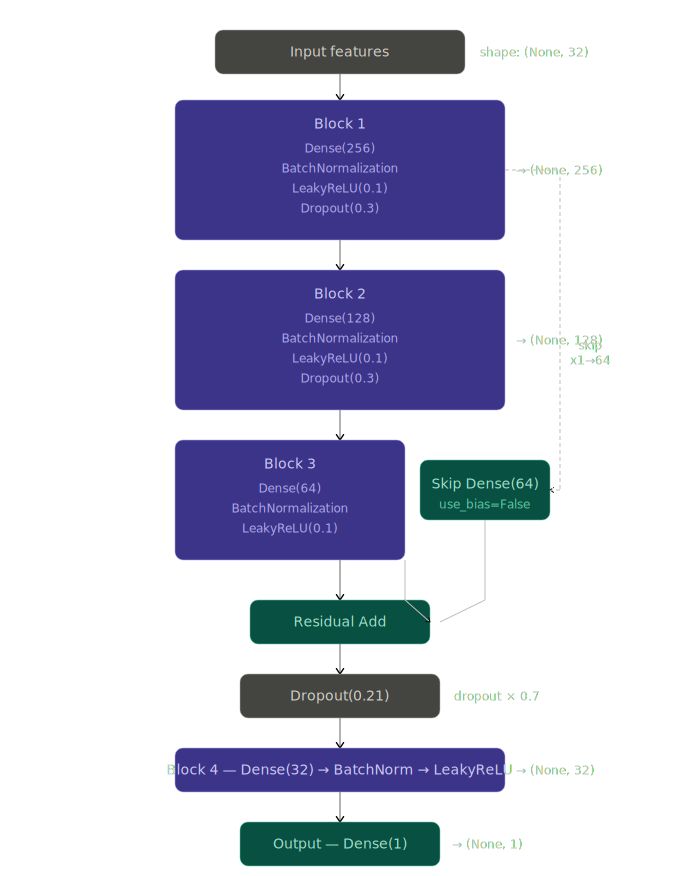

In [41]:
#MLP Architecture
from IPython.display import SVG, display

art = '/kaggle/input/datasets/sumeakash/mlp-architecture/mlp_architecture_32features.svg'

display(SVG(filename=art))

In [42]:
#MLP Architecture
def build_mlp(input_dim, dropout=0.3, l2_reg=1e-4):
    """
    Regularised MLP for regression on tabular financial data.

    Args:
        input_dim : number of input features
        dropout   : fraction of neurons dropped during training (default 0.3)
        l2_reg    : L2 weight penalty to prevent overfitting (default 1e-4)

    Key design choices:
        BatchNorm     → stabilises activations between layers
        LeakyReLU     → prevents dead neurons (unlike ReLU, never outputs zero gradient)
        Skip x1→x3   → gradient shortcut + Block 3 sees early features directly
        Dropout(0.21) → lighter after residual merge; skip already regularises
        L2 on Dense   → penalises large weights so model can't memorise training data

    """
    reg = tf.keras.regularizers.l2(l2_reg)
    inputs = tf.keras.Input(shape=(input_dim,), name='input')

    # ── Block 1: expand into wider representation ─────────────────────────────
    x1 = tf.keras.layers.Dense(256, kernel_regularizer=reg, name='dense1')(inputs)
    x1 = tf.keras.layers.BatchNormalization(name='bn1')(x1)
    x1 = tf.keras.layers.LeakyReLU(0.1, name='act1')(x1)
    x1 = tf.keras.layers.Dropout(dropout, name='drop1')(x1)

    # ── Block 2 ───────────────────────────────────────────────────────────────
    x2 = tf.keras.layers.Dense(128, kernel_regularizer=reg, name='dense2')(x1)
    x2 = tf.keras.layers.BatchNormalization(name='bn2')(x2)
    x2 = tf.keras.layers.LeakyReLU(0.1, name='act2')(x2)
    x2 = tf.keras.layers.Dropout(dropout, name='drop2')(x2)

    # ── Block 3 + Residual skip from Block 1 ─────────────────────────────────
    # Skip connection: projects block1 output (256) → 64 to match block3 size
    skip = tf.keras.layers.Dense(64, kernel_regularizer=reg,
                                  use_bias=False, name='skip')(x1)
    x3   = tf.keras.layers.Dense(64, kernel_regularizer=reg, name='dense3')(x2)
    x3   = tf.keras.layers.BatchNormalization(name='bn3')(x3)
    x3   = tf.keras.layers.LeakyReLU(0.1, name='act3')(x3)
    x3   = tf.keras.layers.Add(name='residual')([x3, skip])   # skip connection
    x3   = tf.keras.layers.Dropout(dropout * 0.7, name='drop3')(x3)

    # ── Block 4: final compression ────────────────────────────────────────────
    x4 = tf.keras.layers.Dense(32, kernel_regularizer=reg, name='dense4')(x3)
    x4 = tf.keras.layers.BatchNormalization(name='bn4')(x4)
    x4 = tf.keras.layers.LeakyReLU(0.1, name='act4')(x4)

    # ── Output ────────────────────────────────────────────────────────────────
    output = tf.keras.layers.Dense(1, name='output')(x4)

    model = tf.keras.Model(inputs=inputs, outputs=output)
    return model


In [43]:
def train_mlp(X, y, tscv, test, epochs=200, batch_size=256, lr=1e-3, dropout=0.3):
    """
    Two phases:
    Phase 1 — Cross-validation: measure honest OOF RMSE (how good is our model?)
    Phase 2 — Full retraining: train on ALL data so final model is as strong as possible.

    Plain: CV tells us the score. Full retrain gives us the best possible model.
    Think of CV as 'practice exams' and full retrain as 'studying everything before the real exam.'
    
    IMPORTANT for time series:
    - shuffle=False everywhere (preserve temporal order)
    - epochs for full retrain = average stopped epoch from CV folds
      (we have no validation set now, so we use CV to decide when to stop)
    """
    rmse_scores    = []
    r2_scores      = []
    histories      = []
    oof_preds      = np.zeros(len(y))
    stopped_epochs = []   # track when each fold stopped → use for full retrain
    y_original = y.copy()
    y_trans = np.sign(y) * np.log1p(np.abs(y))#transform y through logratmic 


    # ══════════════════════════════════════════════════════════════════════════
    # PHASE 1: Cross-Validation (measure performance, collect OOF predictions)
    # ══════════════════════════════════════════════════════════════════════════
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):

        X_train_raw = X.iloc[train_idx].copy()
        X_valid_raw = X.iloc[val_idx].copy()
        y_trans_train = y_trans.iloc[train_idx].values.astype(np.float32)
        y_valid_trans = y_trans.iloc[val_idx].values.astype(np.float32)



        # call impute fxn
        X_train, X_valid = impute_value(X_train_raw, X_valid_raw)


        # Scale: fit on train ONLY → no leakage into validation
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
        X_valid_scaled = scaler.transform(X_valid).astype(np.float32)

        tf.keras.backend.clear_session()
        model = build_mlp(input_dim=X_train_scaled.shape[1], dropout=dropout)

        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=lr, weight_decay=1e-4, clipnorm=1.0
        )
        model.compile(
            optimizer=optimizer,
            loss=tf.keras.losses.Huber(delta=1.0),
            metrics=['mae']
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=20,
                restore_best_weights=True,
                verbose=0
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5,
                patience=10, min_lr=1e-6, verbose=0
            ),
        ]

        history = model.fit(
            X_train_scaled, y_trans_train,
            validation_data=(X_valid_scaled, y_valid_trans),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            shuffle=False,   #  time series — preserve order
            verbose=0
        )
        histories.append(history.history)
        stopped_epoch = len(history.history['loss'])
        stopped_epochs.append(stopped_epoch)

        val_pred = model.predict(X_valid_scaled, verbose=0).flatten()
        val_pred = np.clip(val_pred, -9.5, 9.5)

        pred_original = np.sign(val_pred) * np.expm1(np.abs(val_pred))
        oof_preds[val_idx] = pred_original

        fold_rmse = np.sqrt(mean_squared_error(y_original.iloc[val_idx],pred_original))
        fold_r2   = r2_score(y_original.iloc[val_idx],pred_original)
        rmse_scores.append(fold_rmse)
        r2_scores.append(fold_r2)

        print(f'Fold {fold} | RMSE: {fold_rmse:.4f} | R2: {fold_r2:.4f} '
              f'| stopped epoch: {stopped_epoch}')
        print('-' * 50)

    oof_rmse = np.sqrt(mean_squared_error(y_original.values, oof_preds))
    avg_stopped = int(np.mean(stopped_epochs))

    print(f'\nPhase 1 Complete:')
    print(f'  Average fold RMSE : {np.mean(rmse_scores):.4f}')
    print(f'  Average fold R2   : {np.mean(r2_scores):.4f}')
    print(f'  True OOF RMSE     : {oof_rmse:.4f}')
    print(f'  Avg stopped epoch : {avg_stopped} ')

    # ══════════════════════════════════════════════════════════════════════════
    # PHASE 2: Full Retrain on ALL data
    # ══════════════════════════════════════════════════════════════════════════
    # Plain: Now that we know the model works (from OOF RMSE), we train on
    # everything so the final model has seen as much data as possible.
    #
    # HOW MANY EPOCHS?
    # We have no validation set now, so we can't use early stopping.
    # Instead we use avg_stopped_epoch from CV as our target.
    # We add a small buffer (+10%) because full data usually needs
    # slightly more epochs to converge (more data = slower convergence).
    #
    # WHY NOT USE EARLY STOPPING ON TRAIN LOSS?
    # Training loss always decreases → early stopping on train loss is meaningless.
    # CV-derived epoch count is the correct approach for time series.

    full_retrain_epochs = int(avg_stopped * 1.1)   # +10% buffer
    print(f'\nPhase 2: Retraining on full data for {full_retrain_epochs} epochs...')

    X = X.copy()
    test = test.copy()
    X_train_full, test_df = impute_value(X1, test)


    # Scale full data
    # Plain: now we fit the scaler on ALL training data (no validation split)
    full_scaler   = RobustScaler()
    X_full_scaled = full_scaler.fit_transform(X_train_full).astype(np.float32)
    y_full        = y_trans.values.astype(np.float32)

    

    tf.keras.backend.clear_session()
    final_model = build_mlp(input_dim=X_full_scaled.shape[1], dropout=dropout)

    final_optimizer = tf.keras.optimizers.AdamW(
        learning_rate=lr, weight_decay=1e-4, clipnorm=1.0
    )
    final_model.compile(
        optimizer=final_optimizer,
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )

    # ReduceLROnPlateau on training loss (only option without val set)
    # Plain: still halve LR when training loss plateaus — better than fixed LR.
    final_callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='loss',    # monitor train loss (no val set available)
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=0
        ),
    ]

    final_history = final_model.fit(
        X_full_scaled, y_full,
        epochs=full_retrain_epochs,
        batch_size=batch_size,
        callbacks=final_callbacks,
        shuffle=False,   #  time series — preserve order
        verbose=0
    )

    print(f'Phase 2 Complete: final model trained for {full_retrain_epochs} epochs.')

    return {
        'test_df'       : test_df,
        'final_model'   : final_model,    # ← use THIS for test predictions
        'final_scaler'  : full_scaler,
        'histories'     : histories,
        'final_history' : final_history.history,
        'oof_preds'     : oof_preds,
        'avg_rmse'      : np.mean(rmse_scores),
        'avg_r2'        : np.mean(r2_scores),
        'oof_rmse'      : oof_rmse,
        'stopped_epochs': stopped_epochs,
    }


result_tab = train_mlp(X1, y1, tscv,test)

I0000 00:00:1780824309.935288      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780824309.940490      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1780824315.001679     355 service.cc:152] XLA service 0x7acb6c012a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780824315.001776     355 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780824315.001783     355 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780824315.902561     355 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780824319.893882     355 device_compiler.h:188] Compiled clust

Fold 1 | RMSE: 615.3503 | R2: -3.4531 | stopped epoch: 21
--------------------------------------------------
Fold 2 | RMSE: 106.7615 | R2: -0.0593 | stopped epoch: 120
--------------------------------------------------
Fold 3 | RMSE: 412.6833 | R2: -135.4647 | stopped epoch: 21
--------------------------------------------------
Fold 4 | RMSE: 47.7401 | R2: -0.1623 | stopped epoch: 22
--------------------------------------------------
Fold 5 | RMSE: 77.3064 | R2: -0.0623 | stopped epoch: 125
--------------------------------------------------

Phase 1 Complete:
  Average fold RMSE : 251.9683
  Average fold R2   : -27.8403
  True OOF RMSE     : 309.1497
  Avg stopped epoch : 61 

Phase 2: Retraining on full data for 67 epochs...
Phase 2 Complete: final model trained for 67 epochs.


In [44]:
fig = go.Figure()

for i, history in enumerate(result_tab['histories'], start=1):

    fig.add_trace(
        go.Scatter(
            y=history['loss'],
            mode='lines',
            name=f'Fold {i} Train'
        )
    )

    fig.add_trace(
        go.Scatter(
            y=history['val_loss'],
            mode='lines',
            name=f'Fold {i} Valid',
            line=dict(dash='dash')
        )
    )

fig.update_layout(
    title='MLP Training vs Validation Loss Across 5 Folds',
    xaxis_title='Epoch',
    yaxis_title='Loss',
    hovermode='x unified',
    height=600
)

fig.show()

# Model comparision

In [45]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'CatBoost', 'MLP_Model'],
    'RMSE': [
        rf_result['avg_rmse'],
        xgb_result['avg_rmse'],
        cat_result['avg_rmse'],
        result_tab['avg_rmse']
    ],
    'R2': [
        rf_result['avg_r2'],
        xgb_result['avg_r2'],
        cat_result['avg_r2'],
        result_tab['avg_r2']
    ]
})

fig = px.bar(
    comparison,
    x='Model',
    y='RMSE',
    text='RMSE',
    title='Average RMSE Comparison'
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

fig.show()

In [46]:
fig = px.bar(
    comparison,
    x='Model',
    y='R2',
    text='R2',
    title='Average R2 Comparison'
)

fig.update_traces(
    texttemplate='%{text:.3f}',
    textposition='outside'
)

fig.show()

XGBoost achieved the best average cross-validation performance among the evaluated models.

In [47]:
for fold, (train_idx, valid_idx) in enumerate(tscv.split(X), 1):
    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    print(f"Fold {fold}")
    print("Train mean:", y_train.mean())
    print("Valid mean:", y_valid.mean())
    print("Train std :", y_train.std())
    print("Valid std :", y_valid.std())
    print("-"*50)

Fold 1
Train mean: -2.9905877
Valid mean: 78.160355
Train std : 69.40091705322266
Valid std : 291.6408996582031
--------------------------------------------------
Fold 2
Train mean: 37.584877
Valid mean: 35.13407
Train std : 215.8151397705078
Valid std : 103.74441528320312
--------------------------------------------------
Fold 3
Train mean: 36.767944
Valid mean: -15.266724
Train std : 186.1121368408203
Valid std : 35.33156204223633
--------------------------------------------------
Fold 4
Train mean: 23.759275
Valid mean: -2.8205223
Train std : 163.6992645263672
Valid std : 44.28791427612305
--------------------------------------------------
Fold 5
Train mean: 18.443316
Valid mean: 20.455835
Train std : 148.13145446777344
Valid std : 75.013427734375
--------------------------------------------------


The target distribution varies substantially across time periods. Both the mean and standard deviation of future stock returns change considerably between training and validation folds, indicating non-stationarity and regime shifts in the data. This makes long-horizon stock return prediction particularly challenging.

In [48]:
for fold, (_, val_idx) in enumerate(tscv.split(X)):
    print(f"Fold {fold+1}")
    print(y.iloc[val_idx].quantile([0.5, 0.9, 0.95, 0.99]))
    print("-"*50)

Fold 1
0.50     40.200001
0.90    162.107996
0.95    242.134003
0.99    572.246812
Name: return_pct, dtype: float64
--------------------------------------------------
Fold 2
0.50     22.150000
0.90     90.549997
0.95    127.323997
0.99    301.731598
Name: return_pct, dtype: float64
--------------------------------------------------
Fold 3
0.50   -15.750000
0.90    21.320000
0.95    37.753999
0.99    91.484001
Name: return_pct, dtype: float64
--------------------------------------------------
Fold 4
0.50     -7.550000
0.90     41.096000
0.95     65.024002
0.99    157.722805
Name: return_pct, dtype: float64
--------------------------------------------------
Fold 5
0.50      9.620000
0.90     66.371999
0.95     96.540001
0.99    262.039208
Name: return_pct, dtype: float64
--------------------------------------------------


Stock returns are highly unpredictable and change significantly over time. The distribution of returns varies across different periods, making it difficult for models trained only on company fundamentals to accurately predict future returns.

In [49]:
test_df = rf_result['test_df']

rf_pred  = rf_model.predict(test_df)
cat_pred = cat_model.predict(test_df)
xgb_pred = xgb_model.predict(test_df)

ensemble_pred = (
    0.4 * rf_pred +
    0.3 * cat_pred + 
    0.3 * xgb_pred
) 

In [50]:
submission1 = pd.DataFrame({
    "id": id,
    "return_pct": ensemble_pred
})



submission1.to_csv("submission.csv", index=False)

In [51]:
ensemble_pred2 = (
    0.5 * rf_pred +
    0.5 * cat_pred 
) 

submission2 = pd.DataFrame({
    "id": id,
    "return_pct": ensemble_pred2
})



submission2.to_csv("submission.csv", index=False)


In [52]:
submission3 = pd.DataFrame({
    "id": id,
    "return_pct": cat_pred
})



submission3.to_csv("submission.csv", index=False)

In [53]:
submission4 = pd.DataFrame({
    "id": id,
    "return_pct": xgb_pred
})



submission4.to_csv("submission.csv", index=False)

In [54]:
ens_pred = (
    0.5 * rf_pred +
    0.5 * xgb_pred 
) 
submission5 = pd.DataFrame({
    "id": id,
    "return_pct": ens_pred
})



submission5.to_csv("submission.csv", index=False)

In [55]:
submission1.head()

,id,return_pct
0,0,-9.145264
1,1,4.930127
2,2,3.890431
3,3,-0.320996
4,4,0.125033


# Business Insights

### Missing Values

Many companies, particularly growth-oriented firms, do not pay dividends. Therefore, missing values in dividend-related features may contain useful information rather than indicating poor data quality.

### Correlation Analysis

No single financial metric strongly explains future stock returns. This suggests that stock performance is influenced by multiple interacting factors rather than any one variable.

### Model Selection

Tree-based ensemble models were more effective at capturing the complex non-linear relationships between company fundamentals and future stock returns.

### Model Performance

The relatively low R² score is likely not due to the model alone. Several factors contribute to this challenge:

1. Stock return distributions change over time.
2. Future stock returns are inherently noisy and difficult to predict.
3. Financial fundamentals explain only a portion of future stock performance.

As a result, predicting one-year stock returns using only fundamental data remains a challenging task.
